# Inclination vs mass ratio or chi_p

Notebook to illustrate inference of inclination and mass ratio or chi_p from higher harmonic and precession waveforms.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import copy

In [2]:
import sys

sys.path.append("/home/charlie.hoy/gitlab/simple-pe/") # comment if simple-pe installed
from simple_pe.param_est import metric, pe, result
from scipy.stats import ncx2

import pycbc
from pycbc.conversions import eta_from_q
from scipy.stats import norm
from pesummary.gw.conversions import q_from_eta
from simple_pe.param_est import pe

import event, psd, plots

In [3]:
import logging
_logger = logging.getLogger('PESummary')
_logger.setLevel(logging.CRITICAL + 10)

In [4]:
from seaborn import color_palette

colorblind = color_palette(palette="colorblind", n_colors=2)

### Settings

In [5]:
savefig = True
figdir = '../Figures_for_Paper/'

## Read in event and psd

In [6]:
event_name = "high_rho_p_high_rho_33"
# event_name="high_rho_p"
# event_name = "high_rho_33"
# event_name = "no_rho_p_no_rho_33"

In [7]:
event_exact = event.read_event(event_name)
event_exact = pe.SimplePESamples(event_exact)
event_exact.generate_all_posterior_samples()

In [8]:
tau = np.tan(event_exact['theta_jn']/2)
d_face = event_exact['luminosity_distance'] * (1 + tau**2)**2

In [9]:
alpha = event_exact['alpha_net']
rho_2pol = np.sqrt(event_exact['network_coh_snr']**2 - event_exact['network_left_snr']**2)

In [10]:
approximant="IMRPhenomXPHM"

In [11]:
ifos = ['H1', 'L1', 'V1']

f_low = 15.
f_high = 8192.
length = 32
delta_f = 1. / length

In [12]:
psds = psd.generate_psds(ifos, f_low, f_high, delta_f)

hm_psd = psd.harmonic_mean_psd(psds)

/home/ian.harry/.conda/envs/thapycbcsbank/lib/python3.9/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in true_divide
  return self._data.__rtruediv__(other)


# Mass ratio and inclination

In [13]:
eta_min=0.1
eta_max=0.25

In [14]:
npts = 500

In [15]:
t = np.linspace(0, np.pi/2, npts)
q = np.linspace(1., 8., npts)
thetas, qs = np.meshgrid(t, q)

In [16]:
xhm = pe.SimplePESamples({'theta_jn':thetas.flatten(),
                        'mass_ratio':qs.flatten()
                       })

In [17]:
modes=['33']

interp_directions = ['mass_ratio']
interp_points = 30
xhm.add_fixed('chirp_mass', event_exact['chirp_mass'])
xhm.add_fixed('chi_eff', event_exact['chi_eff'])

In [18]:
xhm.calculate_rho_lm(hm_psd, f_low, event_exact['network_coh_snr'], modes, interp_directions, interp_points,
                         approximant)

calculating alpha_lm on grid:   0%|          | 0/30 [00:00<?, ?it/s]/home/ian.harry/.conda/envs/thapycbcsbank/lib/python3.9/site-packages/pycbc/types/array.py:396: RuntimeWarning: invalid value encountered in true_divide
  self._data /= other
/home/ian.harry/.conda/envs/thapycbcsbank/lib/python3.9/site-packages/pycbc/types/array.py:383: RuntimeWarning: invalid value encountered in true_divide
  return self._data / other
calculating alpha_lm on grid: 100%|██████████| 30/30 [00:18<00:00,  1.60it/s]


In [19]:
eta_min=0.125
eta_max=0.195

In [20]:
xhm.calculate_hm_prec_probs(hm_snr={'33':event_exact['network_33_multipole_snr']})

In [21]:
xhm['symmetric_mass_ratio'] = eta_from_q(xhm['mass_ratio'])

In [22]:
xhm['p_eta'] = norm.pdf(xhm['symmetric_mass_ratio'], loc=0.16, scale=0.014)
xhm['p_eta'] /= xhm['p_eta'].max()

In [23]:
xhm['p_eta33'] = xhm['p_eta'] * xhm['p_33']

In [24]:
def plot_theta_q_contours(x, probs, colours, event_name, colorbar=False):
    plt.figure(figsize=(12,9))
    if len(probs) > 1:
        alpha = 0.7
    else:
        alpha = 1.
    for i, p in enumerate(probs):
        plt.contourf(np.degrees(x['theta_jn']).reshape(npts,npts), 
             x['mass_ratio'].reshape(npts,npts), 
             x[p].reshape(npts,npts), alpha=alpha,
             levels=np.linspace(0.1,1,10),
             cmap=colours[i])
        
    plt.xlabel(r"$\theta_{JN}$ [deg]")
    plt.ylabel('q')
    if colorbar:
        plt.colorbar(label='pdf', ticks=np.linspace(0,1,11))
    plt.plot(np.degrees(event_exact['theta_jn']), event_exact['inverted_mass_ratio'], color=colorblind[1], marker='x', markersize=18, markeredgewidth=3.5)
    if savefig:
        plt.tight_layout()
        plt.savefig('%s/theta_q_from_%s_%s.png' % (figdir, '_'.join(probs), event_name))

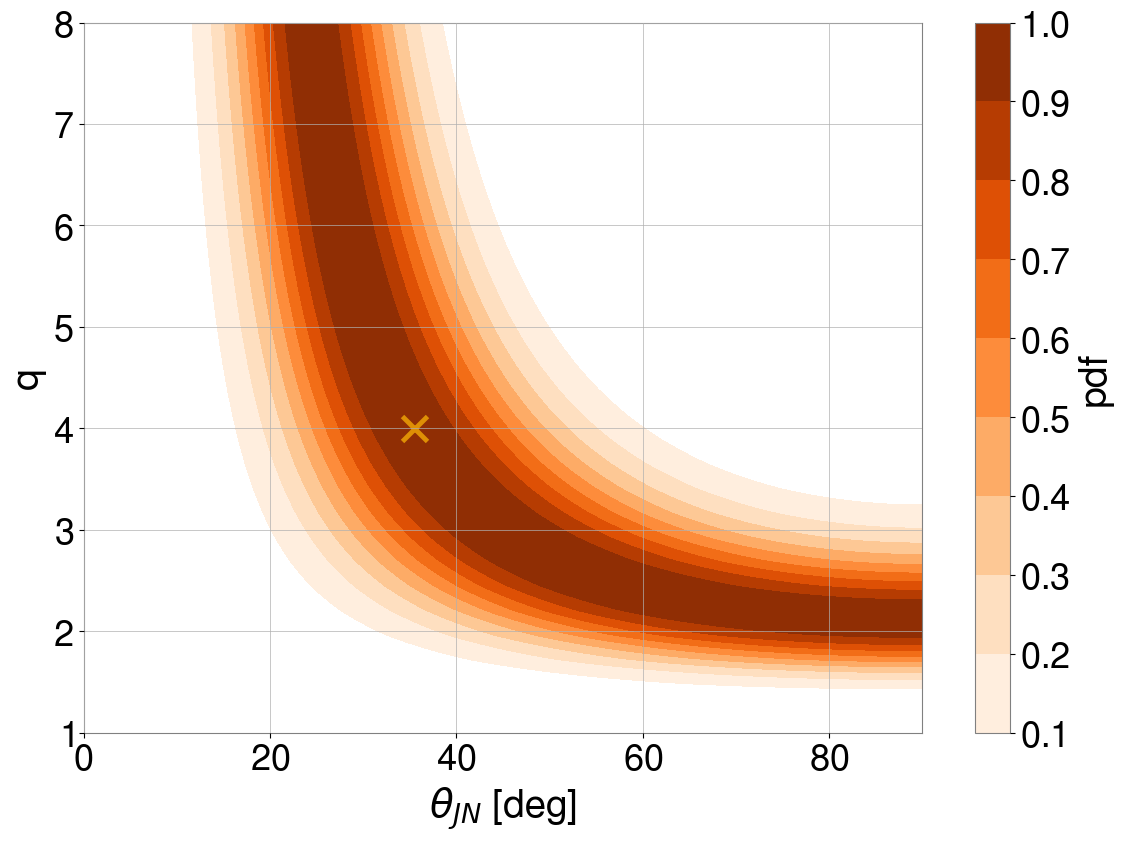

In [25]:
plot_theta_q_contours(xhm, ['p_33'], ['Oranges'], event_name, colorbar=True)

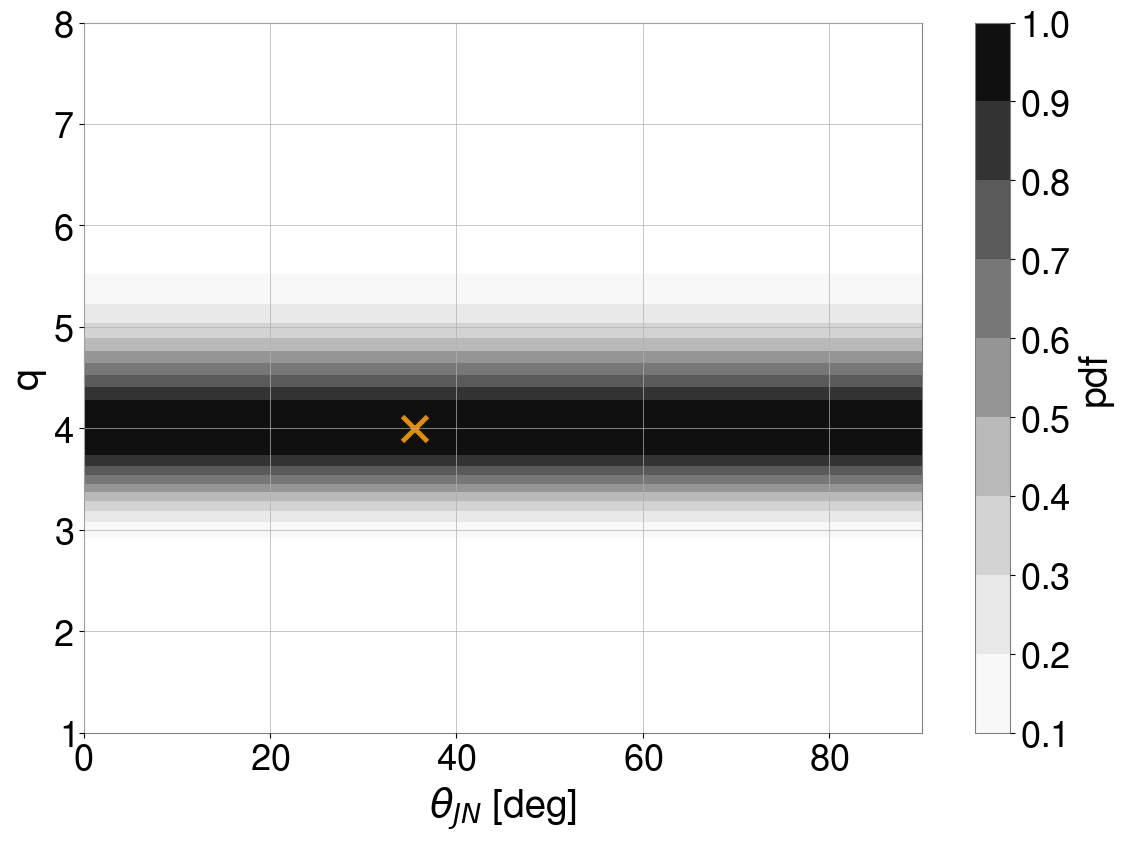

In [26]:
plot_theta_q_contours(xhm, ['p_eta'], ['Greys'], event_name, colorbar=True)

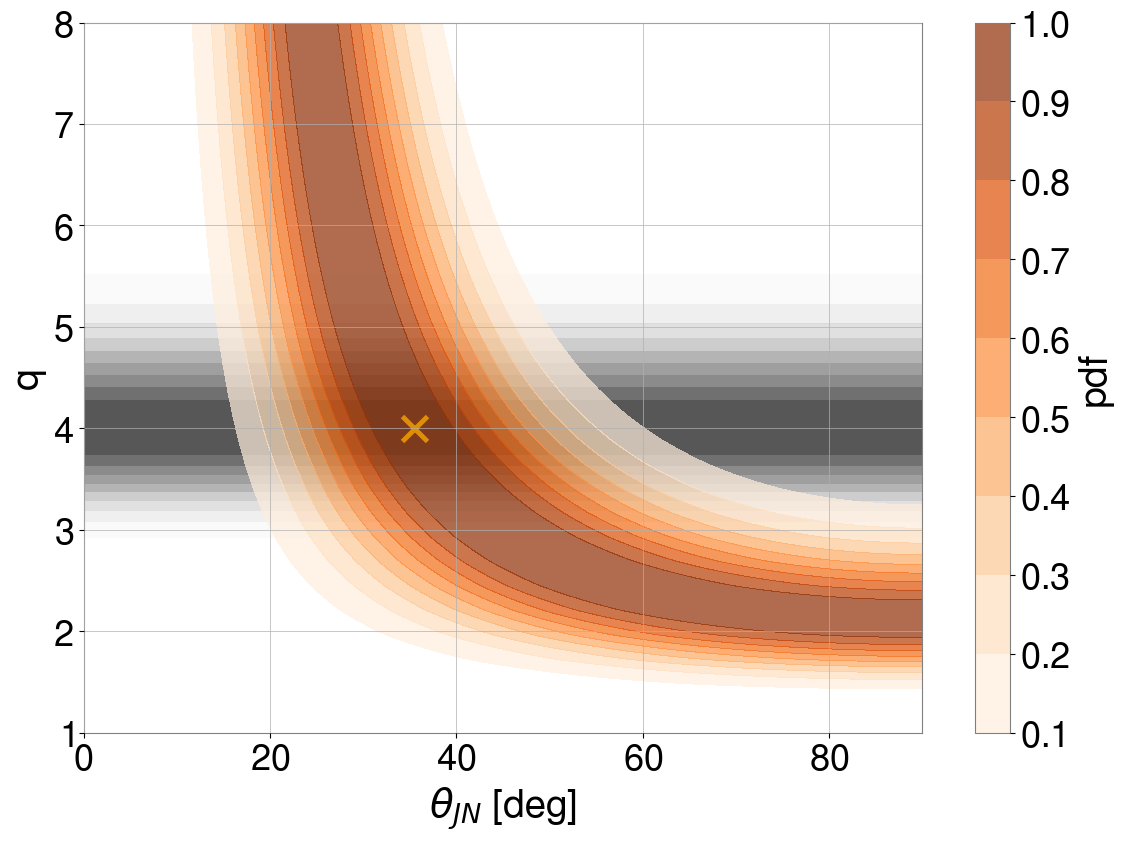

In [27]:
plot_theta_q_contours(xhm, ['p_eta', 'p_33'], ['Greys', 'Oranges'], event_name, colorbar=True)

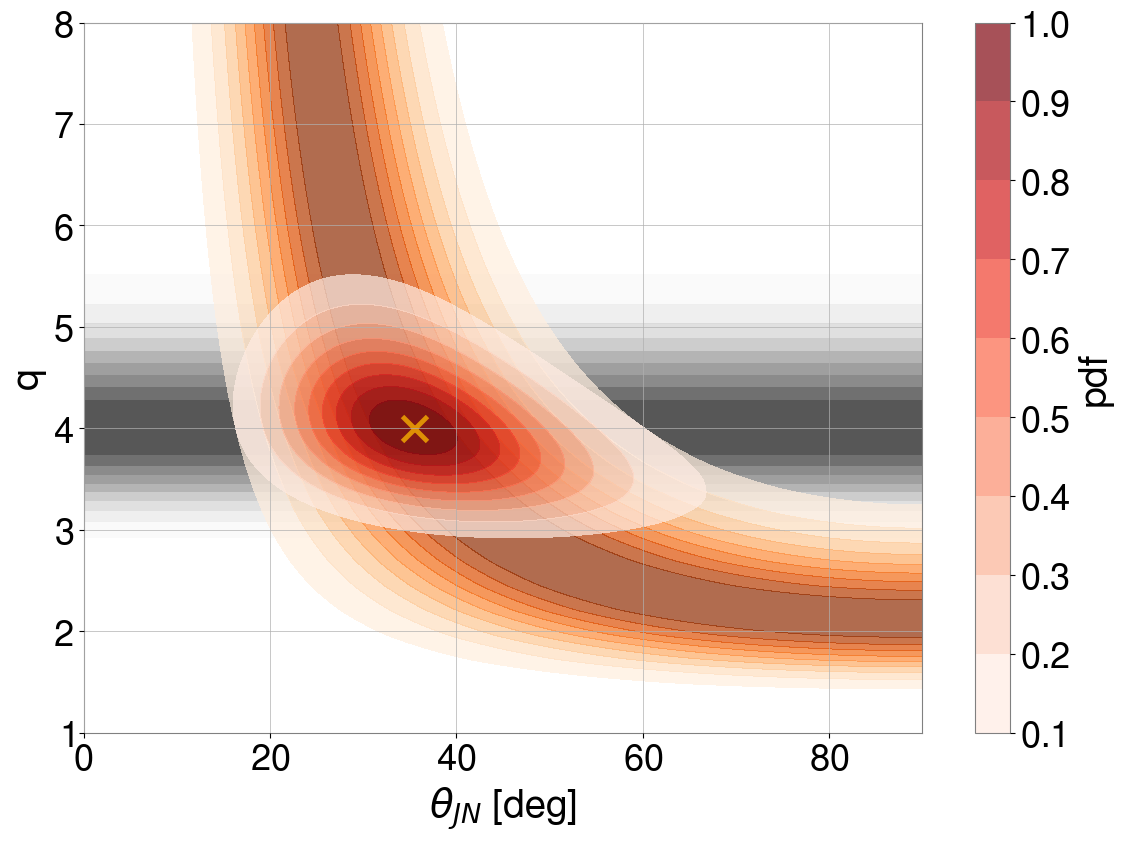

In [ ]:
plot_theta_q_contours(xhm, ['p_eta', 'p_33', 'p_eta33'], ['Greys', 'Oranges', 'Reds'], event_name, colorbar=True)

# Chi_p and inclination

In [ ]:
chip_min = 0.
chip_max = 0.9

In [ ]:
npts = 500

In [ ]:
t = np.linspace(0, np.pi/2, npts)
c = np.linspace(0., 0.9, npts)
thetas, chis = np.meshgrid(t, c)

In [ ]:
x_prec = pe.SimplePESamples({'theta_jn':thetas.flatten(),
                        'chi_p':chis.flatten()
                       })

In [ ]:
interp_directions = ['chi_p']
interp_points = 120
x_prec.add_fixed('chirp_mass', event_exact['chirp_mass'])
x_prec.add_fixed('symmetric_mass_ratio', event_exact['symmetric_mass_ratio'])
x_prec.add_fixed('chi_eff', event_exact['chi_eff'])

In [ ]:
x_prec.calculate_rho_p(hm_psd, f_low, event_exact['network_coh_snr'], interp_directions, interp_points,
                       approximant="IMRPhenomXPHM")

calculating opening angle on grid: 100%|██████████| 120/120 [02:00<00:00,  1.00s/it]


In [ ]:
x_prec.calculate_hm_prec_probs(prec_snr=event_exact['network_precessing_snr'])

Want to take probability distribution for theta_jn from the HM results above

In [ ]:
x_prec['p_eta33'] = np.outer(np.ones(npts), np.sum(xhm['p_eta33'].reshape(npts, npts), axis=0)).flatten()
x_prec['p_eta33'] /= x_prec['p_eta33'].max()

In [ ]:
x_prec['p_p_eta33'] = x_prec['p_eta33'] * x_prec['p_p']

In [ ]:
def plot_theta_chip_contours(x, probs, colours, event_name, colorbar=False):
    plt.figure(figsize=(12,9))
    if len(probs) > 1:
        alpha = 0.7
    else:
        alpha = 1.
    for i, p in enumerate(probs):
        plt.contourf(np.degrees(x['theta_jn']).reshape(npts,npts), 
             x['chi_p'].reshape(npts,npts), 
             x[p].reshape(npts,npts), alpha=alpha,
             levels=np.linspace(0.1,1,10),
             cmap=colours[i])
        
    plt.xlabel(r"$\theta_{JN}$ [deg]")
    plt.ylabel(r'$\chi_{p}$')
    if colorbar:
        plt.colorbar(label='posterior', ticks=np.linspace(0,1,11))
    plt.plot(np.degrees(event_exact['theta_jn']), event_exact['chi_p'], color=colorblind[1], marker='x', markersize=18, markeredgewidth=3.5)
    if savefig:
        plt.tight_layout()
        plt.savefig('%s/theta_chip_from_%s_%s.png' % (figdir, '_'.join(probs), event_name))

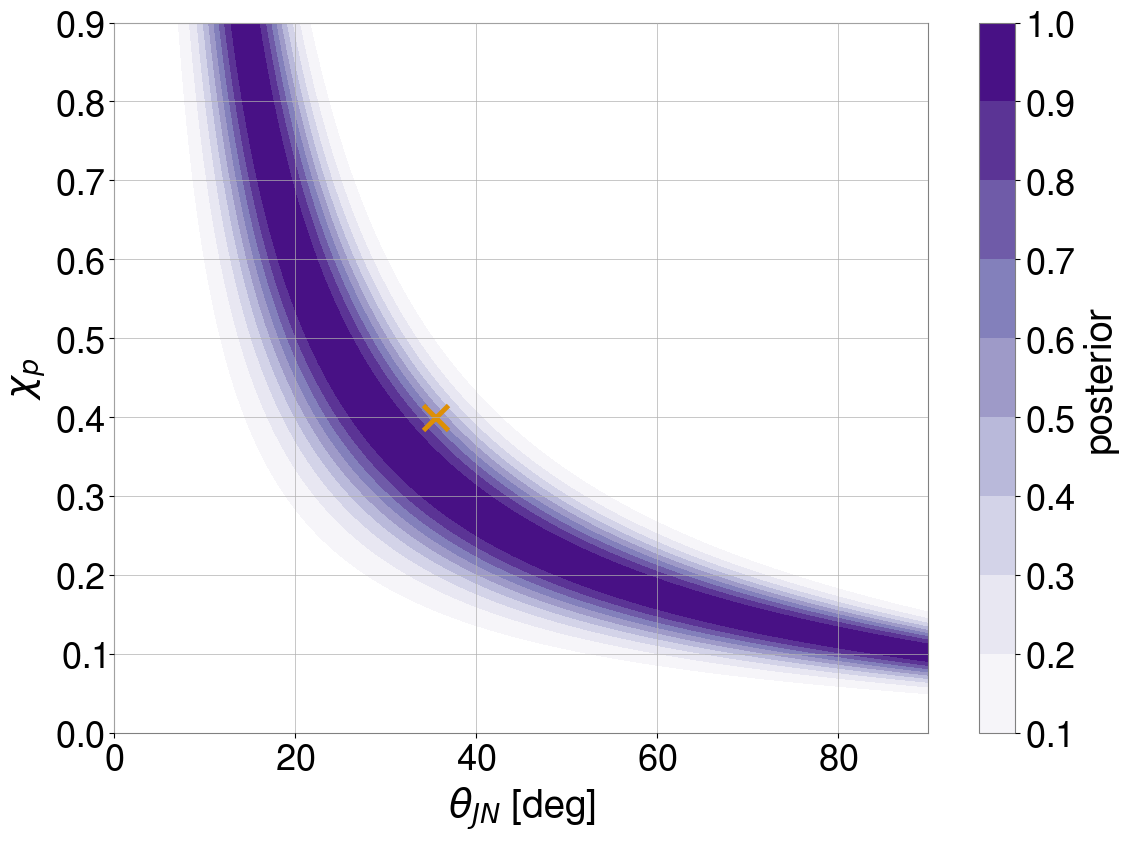

In [ ]:
plot_theta_chip_contours(x_prec, ['p_p'], ['Purples'], event_name, colorbar=True)

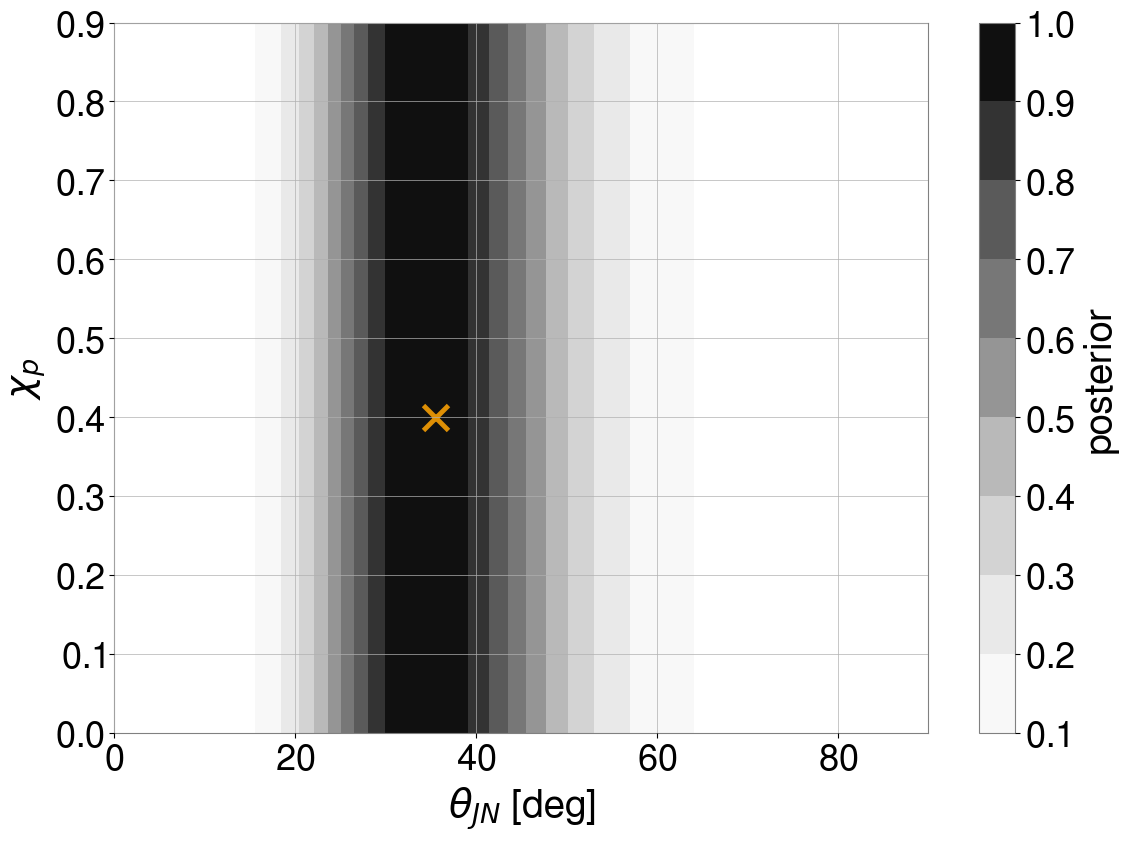

In [ ]:
plot_theta_chip_contours(x_prec, ['p_eta33'], ['Greys'], event_name, colorbar=True)

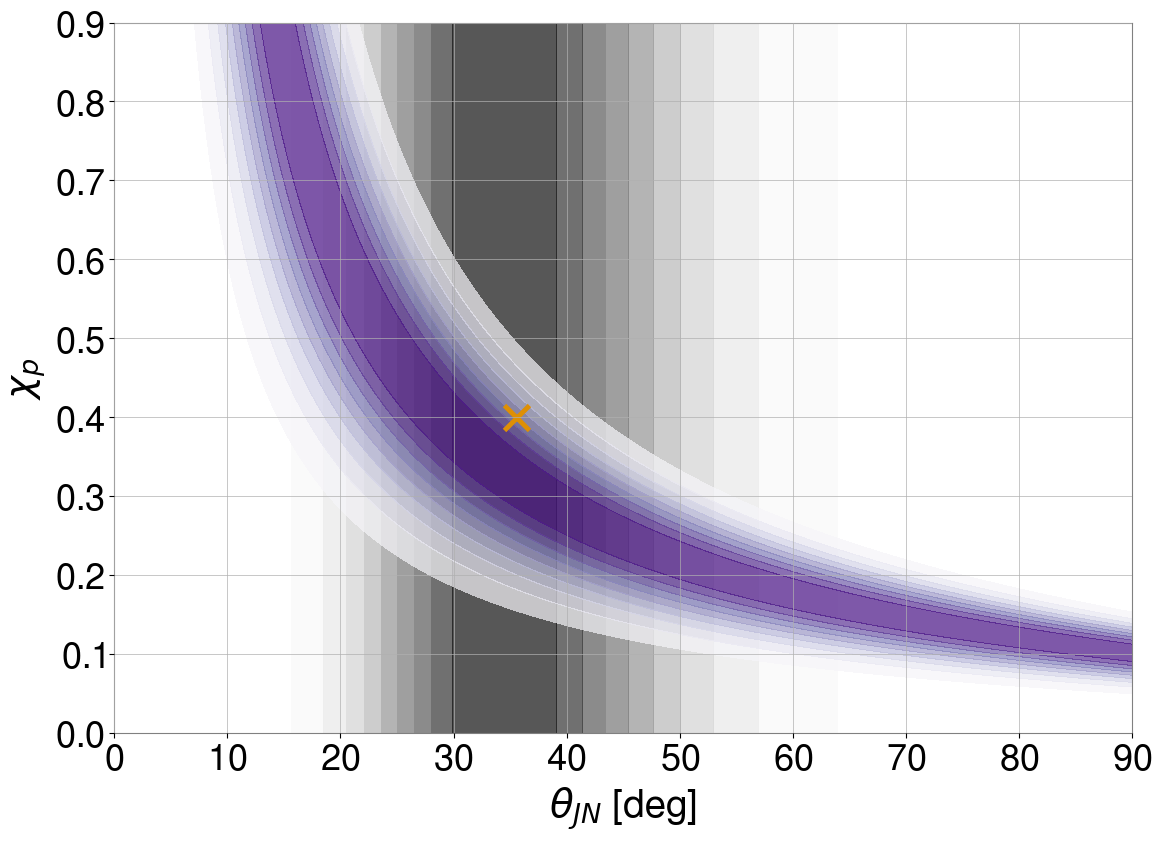

In [ ]:
plot_theta_chip_contours(x_prec, ['p_eta33','p_p'], ['Greys', 'Purples'], event_name, colorbar=False)

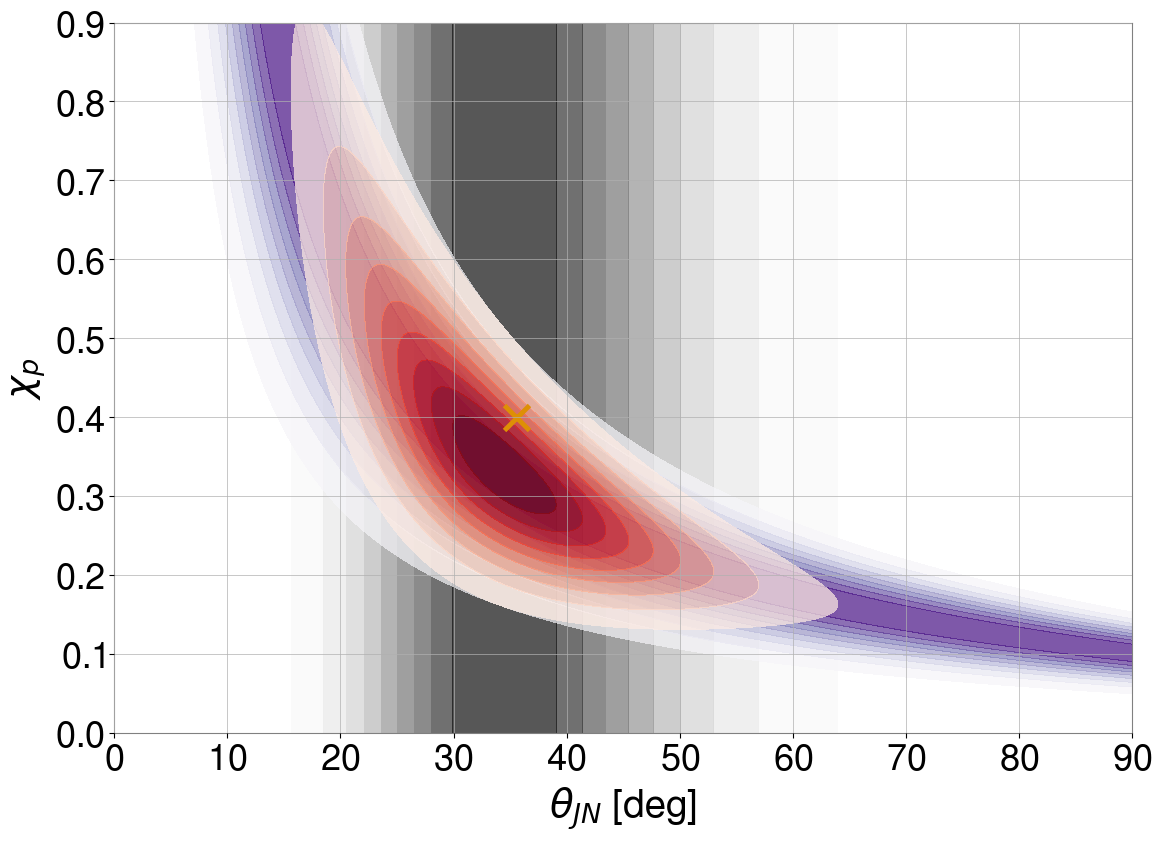

In [ ]:
plot_theta_chip_contours(x_prec, ['p_eta33','p_p', 'p_p_eta33'], ['Greys', 'Purples', 'Reds'], 
                         event_name, colorbar=False)